In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df=pd.read_csv(r"C:\Users\niranjana\OneDrive\Desktop\PDA\PDA 2\laptop_price_dataset_v4.csv")
df.head

<bound method NDFrame.head of      brand  category       cpu  ram ram_type storage  ssd ssd_size  \
0     Asus      Home   Ryzen 7    8     DDR3   512GB  Yes    256GB   
1       HP    Gaming   Ryzen 7   16     DDR3     1TB  Yes    256GB   
2     Dell   Student  Intel i3    4     DDR4     1TB  Yes      1TB   
3     Acer   Student   Ryzen 5    4     DDR5   256GB  Yes      1TB   
4      MSI    Gaming  Intel i7   12     DDR3   256GB  Yes    512GB   
...    ...       ...       ...  ...      ...     ...  ...      ...   
4995  Asus    Gaming   Ryzen 3    8     DDR3     2TB  Yes    256GB   
4996   MSI  Business  Intel i7   12     DDR3   512GB  Yes    256GB   
4997  Dell  Business  Intel i7   16     DDR4   256GB  Yes    256GB   
4998  Asus   Student  Intel i7    8     DDR5   256GB  Yes    256GB   
4999  Dell      Home  Intel i5   16     DDR5     2TB  Yes    512GB   

     graphics_card graphics_card_size  size_inch          os  battery_wh  \
0              AMD                2GB       13.0  Win

In [13]:
df.tail()

,brand,category,cpu,ram,ram_type,storage,ssd,ssd_size,graphics_card,graphics_card_size,size_inch,os,battery_wh,weight_kg,price
4995,Asus,Gaming,Ryzen 3,8,DDR3,2TB,Yes,256GB,Integrated,NaN,15.6,Windows 11,60,1.8,90573
4996,MSI,Business,Intel i7,12,DDR3,512GB,Yes,256GB,AMD,4GB,16.0,Windows 11,55,2.0,104696
4997,Dell,Business,Intel i7,16,DDR4,256GB,Yes,256GB,Nvidia,6GB,16.0,Windows 11,60,2.3,115464
4998,Asus,Student,Intel i7,8,DDR5,256GB,Yes,256GB,AMD,2GB,14.0,Windows 11,70,1.8,85304
4999,Dell,Home,Intel i5,16,DDR5,2TB,Yes,512GB,Integrated,NaN,13.0,Windows 10,60,2.6,90690


In [14]:
df.shape

(5000, 15)

In [15]:
df.columns

Index(['brand', 'category', 'cpu', 'ram', 'ram_type', 'storage', 'ssd',
       'ssd_size', 'graphics_card', 'graphics_card_size', 'size_inch', 'os',
       'battery_wh', 'weight_kg', 'price'],
      dtype='object')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   brand               5000 non-null   object 
 1   category            5000 non-null   object 
 2   cpu                 5000 non-null   object 
 3   ram                 5000 non-null   int64  
 4   ram_type            5000 non-null   object 
 5   storage             5000 non-null   object 
 6   ssd                 5000 non-null   object 
 7   ssd_size            4526 non-null   object 
 8   graphics_card       5000 non-null   object 
 9   graphics_card_size  2691 non-null   object 
 10  size_inch           5000 non-null   float64
 11  os                  5000 non-null   object 
 12  battery_wh          5000 non-null   int64  
 13  weight_kg           5000 non-null   float64
 14  price               5000 non-null   int64  
dtypes: float64(2), int64(3), object(10)
memory usage: 586.1

In [17]:
df.isnull().sum()

brand                    0
category                 0
cpu                      0
ram                      0
ram_type                 0
storage                  0
ssd                      0
ssd_size               474
graphics_card            0
graphics_card_size    2309
size_inch                0
os                       0
battery_wh               0
weight_kg                0
price                    0
dtype: int64

In [18]:
df.ffill(inplace=True)

In [19]:
df.describe()

,ram,size_inch,battery_wh,weight_kg,price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12.788800,14.667240,59.958000,1.853940,102930.118600
std,6.875467,1.217601,11.949761,0.461236,28869.754336
min,4.000000,13.000000,45.000000,1.200000,44279.000000
25%,8.000000,14.000000,50.000000,1.400000,82470.000000
50%,12.000000,15.600000,55.000000,1.800000,98751.500000
75%,16.000000,16.000000,70.000000,2.300000,117701.000000
max,24.000000,16.000000,80.000000,2.600000,214882.000000


<function matplotlib.pyplot.show(close=None, block=None)>

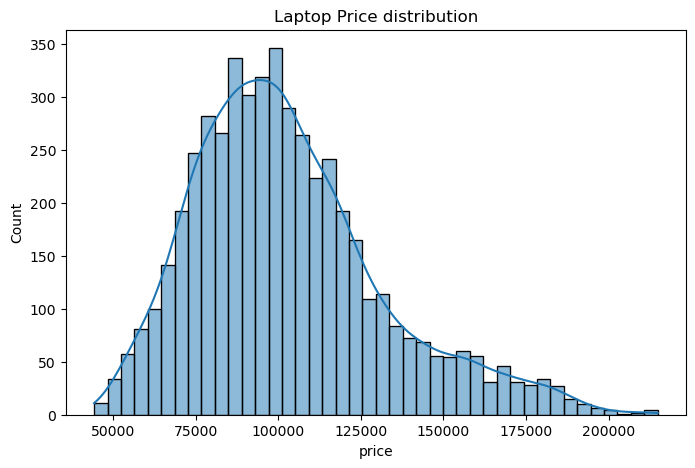

In [20]:
#price Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['price'],kde=True)
plt.title("Laptop Price distribution")
plt.show


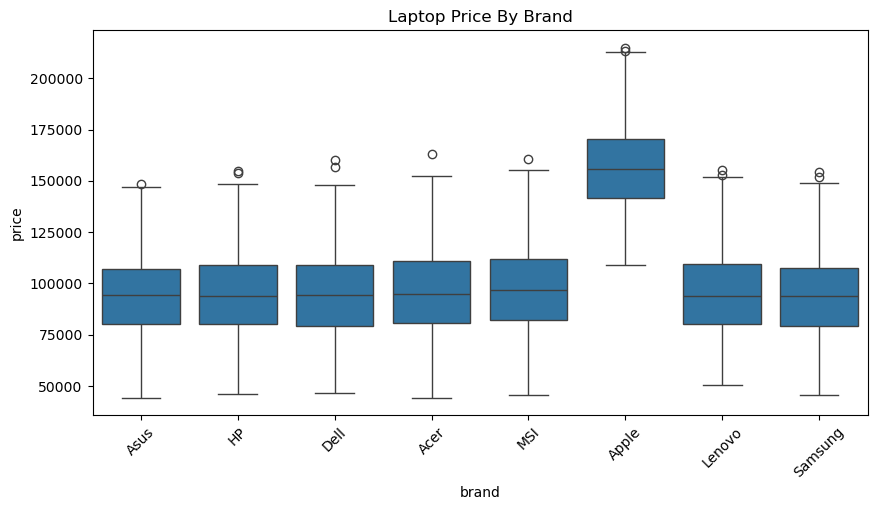

In [25]:
#price by brand
plt.figure(figsize=(10,5))
sns.boxplot(x='brand',y='price',data=df)
plt.title("Laptop Price By Brand")
plt.xticks(rotation=45)
plt.show()

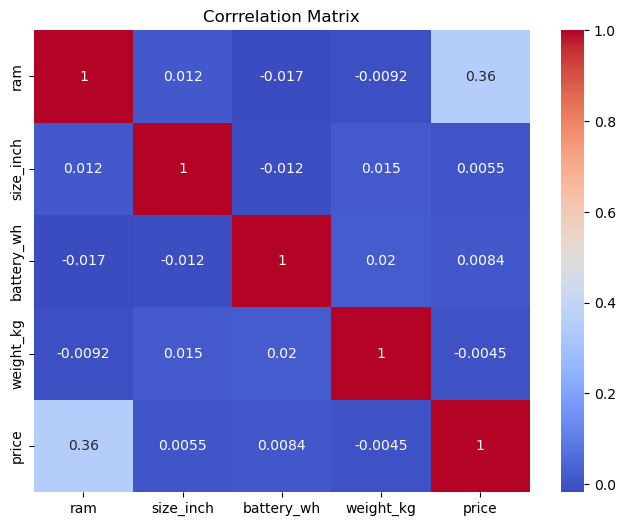

In [30]:
#correction analysis
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,cmap="coolwarm")
plt.title("Corrrelation Matrix")
plt.show()

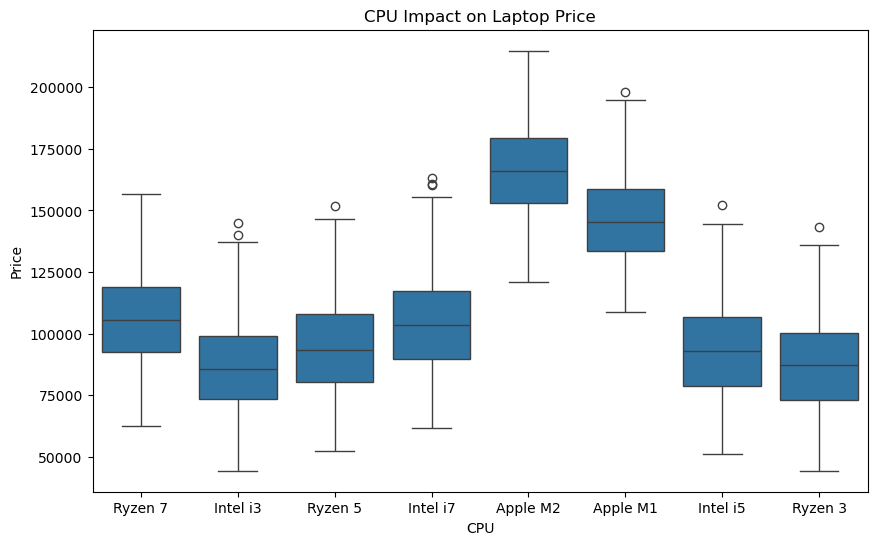

In [46]:
#cpu impact on price
plt.figure(figsize=(10,6))
sns.boxplot(x="cpu",y="price",data=df)
plt.title("CPU Impact on Laptop Price")
plt.xlabel("CPU")
plt.ylabel("Price")
plt.show()

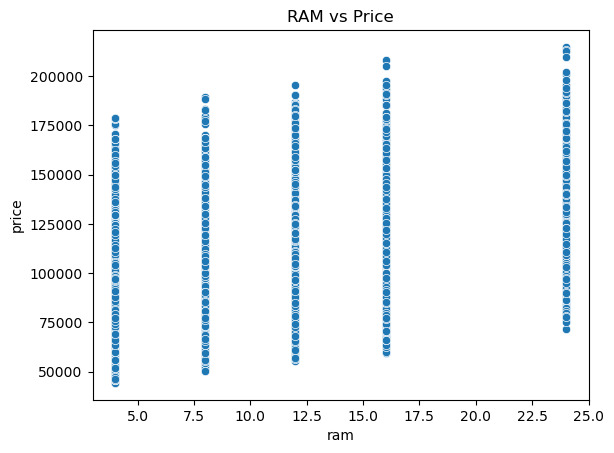

In [34]:
#ram signifcantly increase prices
df.groupby("ram")["price"].mean()
sns.scatterplot(x="ram",y="price",data=df)
plt.title("RAM vs Price")
plt.show()

brand
Apple     214882
Acer      163288
MSI       160886
Dell      160186
Lenovo    155313
Name: price, dtype: int64


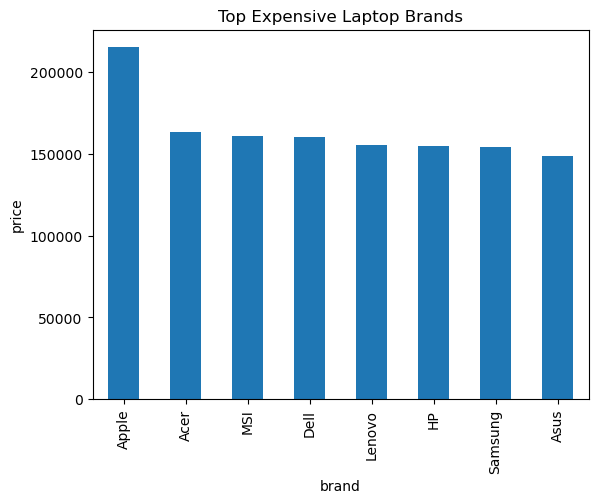

In [40]:
brand_price=df.groupby("brand")["price"].max().sort_values(ascending=False)
print(brand_price.head())
#visualization
brand_price.head(10).plot(kind="bar")
plt.title("Top Expensive Laptop Brands")
plt.ylabel("price")
plt.show()

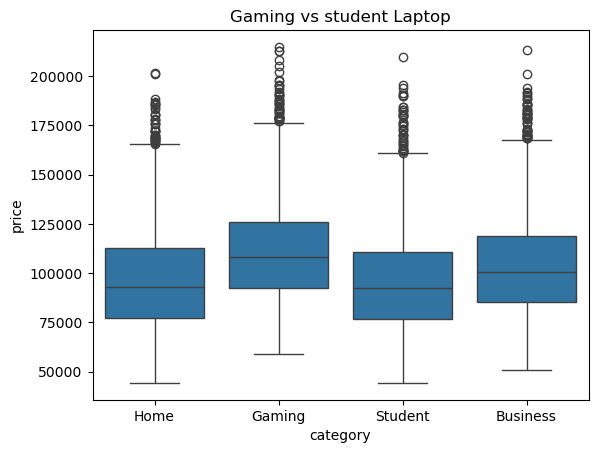

In [42]:
df.groupby("category")["price"].mean()
sns.boxplot(x="category",y="price",data=df)
plt.title("Gaming vs student Laptop")
plt.show()

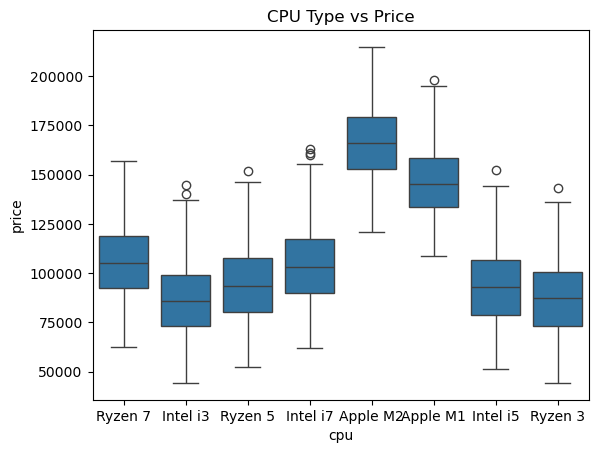

In [43]:
df.groupby("cpu")["price"].mean()
sns.boxplot(x="cpu",y="price",data=df)
plt.title("CPU Type vs Price")
plt.show()

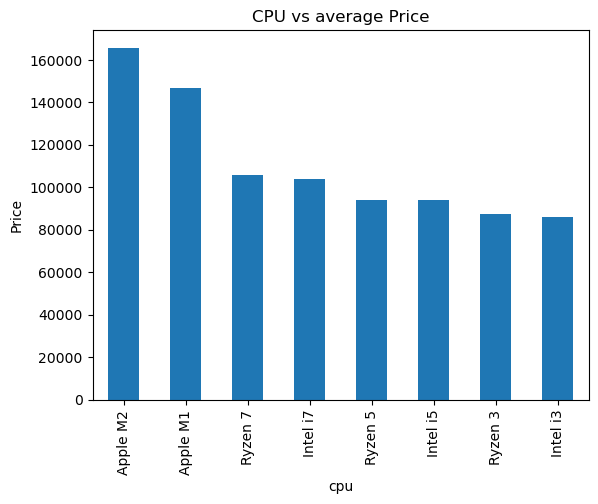

In [52]:
#highest avearge price

top_cpu=df.groupby("cpu")["price"].mean().sort_values(ascending=False).head(10)
top_cpu.plot(kind="bar")
plt.title("CPU vs average Price")
plt.ylabel("Price")
plt.show()